<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/elliptic-pde/dtb_elliptic_single_mode_algorithm_diagnostics_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTB single-mode algorithm diagnostics

This notebook diagnoses the $d=10$ single-mode Poisson experiment by changing one numerical ingredient at a time: tangent dimension $R$, quadrature size $N$, parameter-selection strategy, and outer-loop evolution.

In [1]:
# Clone the requested branch in a fresh Colab session.
import os, subprocess
from pathlib import Path
if Path('DTB_elliptic_utils.py').exists():
    ROOT = Path.cwd()
else:
    ROOT = Path('/content/dtb-colab-experiments')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '-b', 'elliptic-pde', 'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(ROOT)], check=True)
    os.chdir(ROOT)
print('repository:', ROOT)

repository: /content/dtb-colab-experiments


In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
from DTB_elliptic_utils import MLP, flatten_parameters
from dtb_algorithm_diagnosis import (
    SingleModeConfig,
    print_compact_summary,
    run_configuration_sweep,
    run_single_mode_configuration,
    select_tangent_indices,
    selection_counts,
)

torch.set_default_dtype(torch.float64)
DEVICE = torch.device('cpu')

## Parameter guide

- **$d$ — spatial dimension.** The domain is $[-1,1]^d$. This notebook uses $d=10$, where the exact mode is strongly concentrated away from most uniformly sampled points.
- **$p$ — total neural-network parameter count.** It is determined by $d$, width, and depth. DTB does not use all $p$ tangent coordinates here.
- **$R$ — tangent dimension.** DTB selects $R$ parameter derivatives $J_i=\partial_{\theta_i}T_\theta$. Larger $R$ gives a richer trial space, but also enlarges and can destabilize the $R\times R$ stiffness matrix. Always report the selection strategy with $R$.
- **$N$ — training quadrature size.** These $N$ spatial points assemble $G_\theta$ and $b_\theta$. Increasing $R$ without increasing $N$ can fit quadrature error. There is no universal safe ratio, so this notebook reports $N/R$, conditioning, validation error, and energy gaps.
- **$N_{\rm val}$ — independent validation size.** It is never used to construct the inner Ritz system. It measures generalization beyond the training quadrature.
- **Selection strategy.** 'random' samples from the flattened parameter vector. 'layer_balanced' allocates nearly equal counts per layer and retains one bias coordinate per layer, preventing large early-layer blocks from dominating in high dimension.
- **Width and depth.** These control the nonlinear network whose selected parameter derivatives form the tangent basis.
- **$K$ — outer steps.** Each step re-solves the inner coefficients $\alpha$, computes the fixed-$\alpha$ envelope direction, and updates $\theta$.
- **ridge_relative.** The inner solve uses $(G+\lambda I)\alpha=b$ with $\lambda$ scaled by the mean diagonal of $G$. It stabilizes small eigenvalues but changes the inner problem.
- **Probe points.** A fixed independent set used only to compare tangent features and tangent subspaces across outer iterations.

Use $R$ to study trial-space capacity and $N$ to study integration accuracy. Change only one of them within each sweep.

- **LINE_COUNT and PLANE_COUNT — visualization resolution.** These control only the density of the one-dimensional diagnostic curves and two-dimensional coordinate-plane images. They do not enter training, the inner Ritz system, or validation metrics.

- **Seeds.** The model, quadrature, validation, selection, and tangent-probe seeds are held fixed within controlled sweeps. Thus a sweep changes the named experimental variable rather than silently changing the initialization or point set.

In [3]:
# Central experiment controls. Reduce the largest values for a quick smoke test.
D, WIDTH, DEPTH = 10, 16, 2
VALIDATION_N, PROBE_N = 4096, 256
RIDGE_RELATIVE = 1.0e-4

R_VALUES = [16, 32, 64, 128]
FIXED_N_FOR_R_SWEEP = 768

N_VALUES = [768, 2048, 4096, 16384]
FIXED_R_FOR_N_SWEEP = 32
SAMPLE_SWEEP_SELECTION = 'layer_balanced'

OUTER_R, OUTER_N, OUTER_STEPS = 32, 4096, 12
STRATEGIES = ['random', 'layer_balanced']

def configuration(**changes):
    values = dict(
        dimension=D, width=WIDTH, depth=DEPTH,
        validation_count=VALIDATION_N, probe_count=PROBE_N,
        ridge_relative=RIDGE_RELATIVE,
        model_seed=100 + D, quadrature_seed=10 + D,
        selection_seed=700 + D,
    )
    values.update(changes)
    return SingleModeConfig(**values)

# Common evaluation grids used by every controlled configuration.
# The rescaled diagonal x=(rho/sqrt(d))*1 stays inside the box for
# rho in [-sqrt(d), sqrt(d)]. The plane is x=(s,t,0,...,0).
LINE_COUNT, PLANE_COUNT = 161, 41
axis_coordinate = torch.linspace(-1.0, 1.0, LINE_COUNT)
axis_points = torch.zeros(LINE_COUNT, D)
axis_points[:, 0] = axis_coordinate

diagonal_coordinate = torch.linspace(-math.sqrt(D), math.sqrt(D), LINE_COUNT)
diagonal_points = (diagonal_coordinate / math.sqrt(D))[:, None].repeat(1, D)

plane_coordinate = torch.linspace(-1.0, 1.0, PLANE_COUNT)
plane_s, plane_t = torch.meshgrid(plane_coordinate, plane_coordinate, indexing='ij')
plane_points = torch.zeros(PLANE_COUNT**2, D)
plane_points[:, 0] = plane_s.reshape(-1)
plane_points[:, 1] = plane_t.reshape(-1)

EVALUATION_POINTS = {
    'coordinate_axis': axis_points,
    'rescaled_diagonal': diagonal_points,
    'coordinate_plane': plane_points,
}

## Diagnostic 1 — selected-coordinate allocation

**Purpose.** Check whether the same nominal $R$ produces comparable layer coverage. A flattened-random rule can select mostly early-layer weights because that block grows with $d$. The balanced rule should cover every layer, including the output layer.

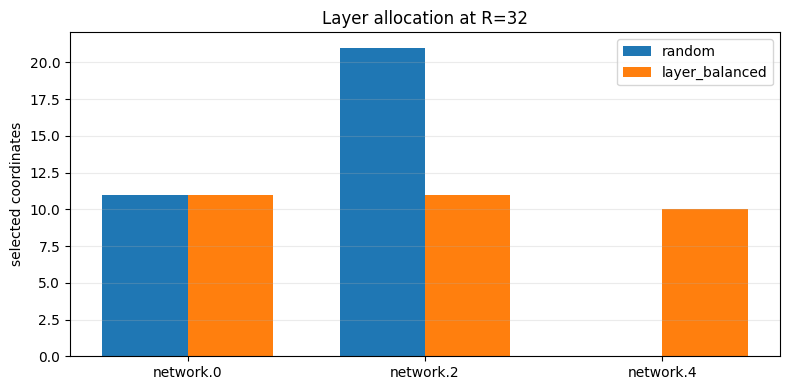

total parameters p = 465


In [4]:
torch.manual_seed(100 + D)
audit_model = MLP(D, width=WIDTH, depth=DEPTH)
audit_theta, audit_spec = flatten_parameters(audit_model)
allocation = {}
for strategy in STRATEGIES:
    indices = select_tangent_indices(
        audit_theta.numel(), audit_spec, FIXED_R_FOR_N_SWEEP,
        strategy, 700 + D,
    )
    allocation[strategy] = selection_counts(indices, audit_spec)

layers = list(next(iter(allocation.values())).keys())
x = np.arange(len(layers)); width = 0.36
fig, axis = plt.subplots(figsize=(8, 4))
for offset, strategy in enumerate(STRATEGIES):
    axis.bar(x + (offset - .5) * width, [allocation[strategy][layer] for layer in layers], width, label=strategy)
axis.set(xticks=x, xticklabels=layers, ylabel='selected coordinates', title=f'Layer allocation at R={FIXED_R_FOR_N_SWEEP}')
axis.grid(axis='y', alpha=.25); axis.legend(); plt.tight_layout(); plt.show()
print('total parameters p =', audit_theta.numel())

## Diagnostic 2 — increase $R$ while holding $N$ fixed

**Purpose.** Test whether extra tangent capacity improves the PDE approximation or merely fits the fixed quadrature. Interpret the metrics together:

- validation relative $L^2$: lower is better;
- $u_{\rm DTB}(0)$: should approach the exact value $1$;
- $\kappa(G)$: rapid growth signals near-dependent tangent features;
- $F_{\rm val}-F_{\rm train}$: a growing positive gap indicates empirical-quadrature overfitting.

Here $N$ remains exactly fixed, so $N/R$ decreases as $R$ grows.

In [5]:
r_configurations = [
    configuration(
        train_count=FIXED_N_FOR_R_SWEEP,
        tangent_dimension=R,
        selection=strategy,
        outer_steps=0,
    )
    for strategy in STRATEGIES for R in R_VALUES
]
r_results = run_configuration_sweep(
    r_configurations, device=DEVICE, evaluation_points=EVALUATION_POINTS
)
for result in r_results:
    print_compact_summary(result)

selection=        random  R= 16  N=  768  L2=3.256e-01  H1=3.621e-01  u(0)=0.540  cond(G)=4.08e+05
selection=        random  R= 32  N=  768  L2=3.607e-01  H1=4.115e-01  u(0)=0.589  cond(G)=9.66e+05
selection=        random  R= 64  N=  768  L2=3.993e-01  H1=4.851e-01  u(0)=0.590  cond(G)=2.37e+07
selection=        random  R=128  N=  768  L2=4.384e-01  H1=5.410e-01  u(0)=0.581  cond(G)=3.33e+09
selection=layer_balanced  R= 16  N=  768  L2=3.236e-01  H1=3.542e-01  u(0)=0.539  cond(G)=6.15e+07
selection=layer_balanced  R= 32  N=  768  L2=3.299e-01  H1=3.692e-01  u(0)=0.580  cond(G)=3.27e+08
selection=layer_balanced  R= 64  N=  768  L2=3.645e-01  H1=4.276e-01  u(0)=0.645  cond(G)=1.46e+09
selection=layer_balanced  R=128  N=  768  L2=4.253e-01  H1=5.273e-01  u(0)=0.576  cond(G)=8.07e+09


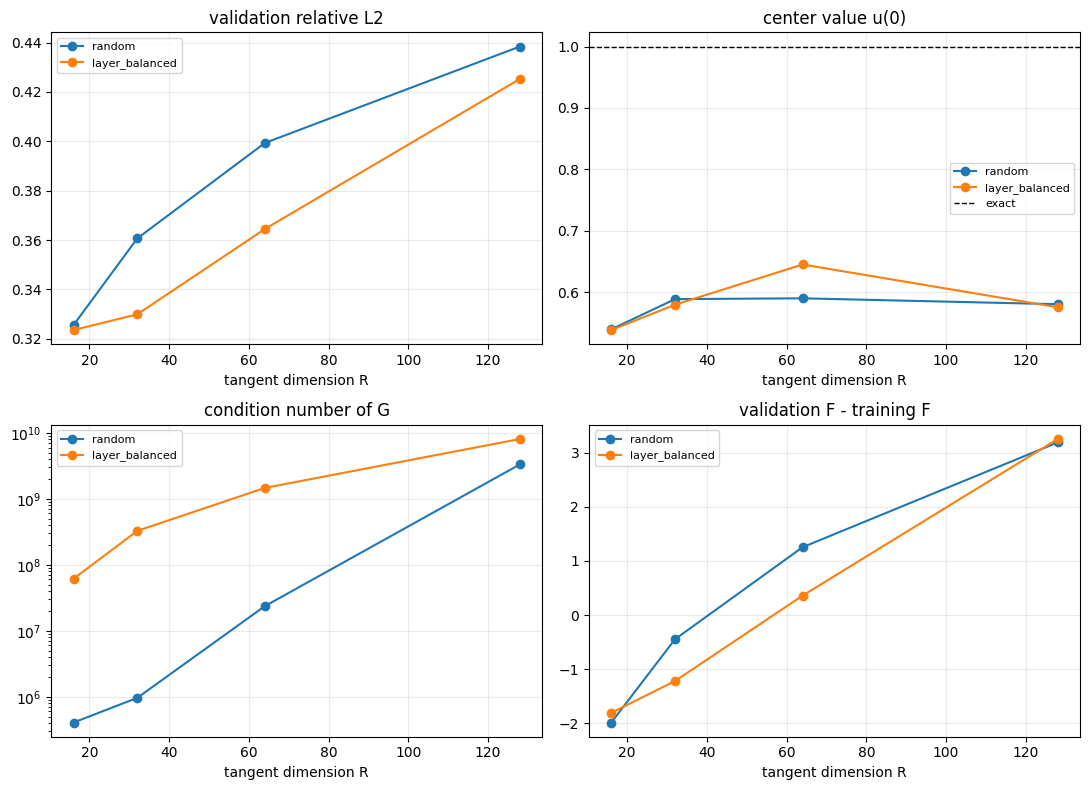

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for strategy in STRATEGIES:
    selected = [result for result in r_results if result['config']['selection'] == strategy]
    R = [result['config']['tangent_dimension'] for result in selected]
    summary = [result['summary'] for result in selected]
    axes[0, 0].plot(R, [row['relative_l2'] for row in summary], 'o-', label=strategy)
    axes[0, 1].plot(R, [row['center_value'] for row in summary], 'o-', label=strategy)
    axes[1, 0].semilogy(R, [row['condition_number'] for row in summary], 'o-', label=strategy)
    axes[1, 1].plot(R, [row['validation_F'] - row['train_F'] for row in summary], 'o-', label=strategy)
axes[0, 1].axhline(1.0, color='k', ls='--', lw=1, label='exact')
titles = ['validation relative L2', 'center value u(0)', 'condition number of G', 'validation F - training F']
for axis, title in zip(axes.flat, titles):
    axis.set(xlabel='tangent dimension R', title=title); axis.grid(alpha=.25); axis.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Diagnostic 3 — increase $N$ while holding $R$ and the selected basis fixed

**Purpose.** Isolate spatial-integration error. All runs reuse the same initialized network, selection seed, $R$, and selection strategy. Only the prefix length of the same scrambled Sobol sequence changes.

- relative $L^2$ and $u(0)$ measure solution improvement;
- exact-energy quadrature error compares the empirical energy of the known exact solution with $-d\pi^2/8$;
- the effective sample size of $u_*^2$ shows how few samples carry most solution mass;
- the central count records points satisfying $\|x\|_\infty<0.5$.

In [7]:
n_configurations = [
    configuration(
        train_count=N,
        tangent_dimension=FIXED_R_FOR_N_SWEEP,
        selection=SAMPLE_SWEEP_SELECTION,
        outer_steps=0,
    )
    for N in N_VALUES
]
n_results = run_configuration_sweep(
    n_configurations, device=DEVICE, evaluation_points=EVALUATION_POINTS
)
for result in n_results:
    print_compact_summary(result)

selection=layer_balanced  R= 32  N=  768  L2=3.299e-01  H1=3.692e-01  u(0)=0.580  cond(G)=3.27e+08
selection=layer_balanced  R= 32  N= 2048  L2=2.481e-01  H1=2.888e-01  u(0)=0.754  cond(G)=3.14e+08
selection=layer_balanced  R= 32  N= 4096  L2=1.713e-01  H1=2.079e-01  u(0)=0.698  cond(G)=2.92e+08
selection=layer_balanced  R= 32  N=16384  L2=1.301e-01  H1=1.667e-01  u(0)=0.692  cond(G)=2.78e+08


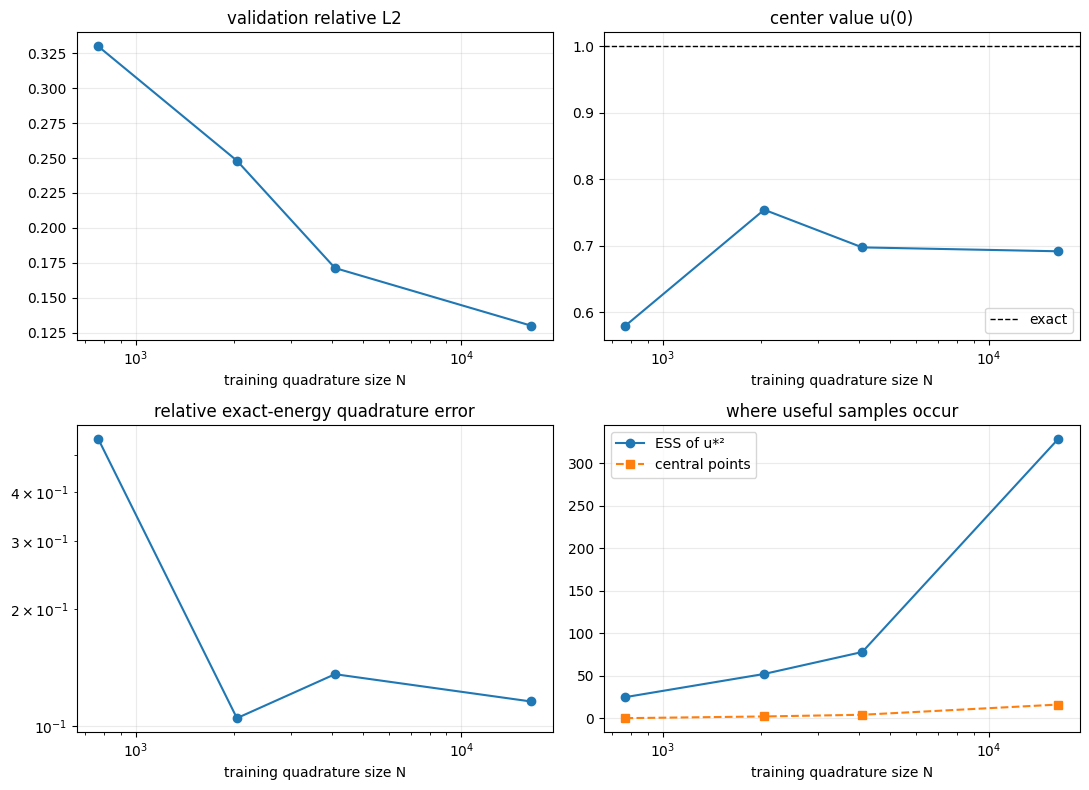

In [8]:
N = [result['config']['train_count'] for result in n_results]
summary = [result['summary'] for result in n_results]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].semilogx(N, [row['relative_l2'] for row in summary], 'o-')
axes[0, 1].semilogx(N, [row['center_value'] for row in summary], 'o-')
axes[0, 1].axhline(1.0, color='k', ls='--', lw=1, label='exact')
energy_error = [abs(row['exact_train_F'] - row['exact_continuous_F']) / abs(row['exact_continuous_F']) for row in summary]
axes[1, 0].loglog(N, energy_error, 'o-')
axes[1, 1].semilogx(N, [row['u_squared_effective_sample_size'] for row in summary], 'o-', label='ESS of u*²')
axes[1, 1].semilogx(N, [row['central_sample_count'] for row in summary], 's--', label='central points')
titles = ['validation relative L2', 'center value u(0)', 'relative exact-energy quadrature error', 'where useful samples occur']
for axis, title in zip(axes.flat, titles):
    axis.set(xlabel='training quadrature size N', title=title); axis.grid(alpha=.25)
axes[0, 1].legend(); axes[1, 1].legend(); plt.tight_layout(); plt.show()

## Diagnostic 4 — does the outer loop update the tangent basis?

**Purpose.** Separate optimizer activity from a meaningful trial-space change.

- relative_theta_change: cumulative parameter movement;
- relative_feature_change: raw Frobenius change of $J_\theta$ on fixed probe points;
- maximum_subspace_sine: sine of the largest principal angle between the initial and current feature spans; it remains near zero if features only rescale or mix inside the same span;
- relative_prediction_change: total change in the re-solved DTB prediction on probe points;
- accepted step and gradient norm: whether Armijo permits meaningful motion;
- training $F$ versus validation $L^2$: whether the changed basis actually improves the PDE approximation.

A decreasing training energy with flat subspace rotation or worsening validation error means that the outer loop is not providing useful basis adaptation.

In [9]:
outer_configurations = [
    configuration(
        train_count=OUTER_N,
        tangent_dimension=OUTER_R,
        selection=strategy,
        outer_steps=OUTER_STEPS,
    )
    for strategy in STRATEGIES
]
outer_results = run_configuration_sweep(
    outer_configurations, device=DEVICE, evaluation_points=EVALUATION_POINTS
)
for result in outer_results:
    print_compact_summary(result)

selection=        random  R= 32  N= 4096  L2=1.971e-01  H1=2.466e-01  u(0)=0.710  cond(G)=8.00e+05
selection=layer_balanced  R= 32  N= 4096  L2=1.858e-01  H1=2.243e-01  u(0)=0.725  cond(G)=5.01e+08


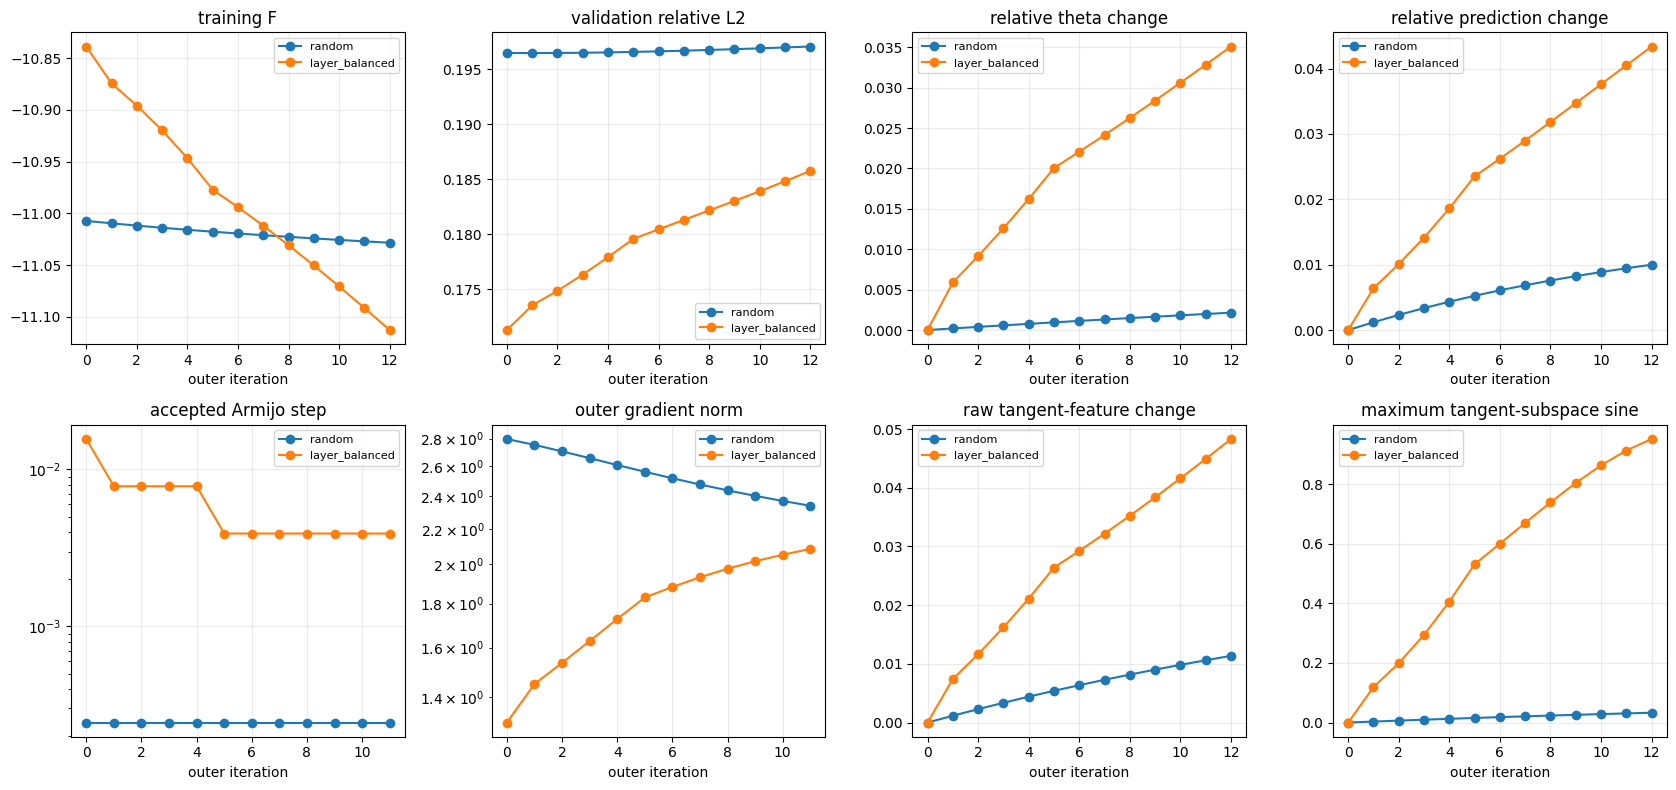

In [10]:
metrics = [
    ('train_F', 'training F', False),
    ('relative_l2', 'validation relative L2', False),
    ('relative_theta_change', 'relative theta change', False),
    ('relative_prediction_change', 'relative prediction change', False),
    ('accepted_step', 'accepted Armijo step', True),
    ('gradient_norm', 'outer gradient norm', True),
    ('relative_feature_change', 'raw tangent-feature change', False),
    ('maximum_subspace_sine', 'maximum tangent-subspace sine', False),
]
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for result in outer_results:
    strategy = result['config']['selection']; history = result['history']
    steps = np.array([row['outer_step'] for row in history])
    for axis, (key, title, logarithmic) in zip(axes.flat, metrics):
        values = np.array([row[key] for row in history], dtype=float)
        valid = np.isfinite(values)
        if logarithmic:
            axis.semilogy(steps[valid], values[valid], 'o-', label=strategy)
        else:
            axis.plot(steps[valid], values[valid], 'o-', label=strategy)
        axis.set(xlabel='outer iteration', title=title)
for axis in axes.flat:
    axis.grid(alpha=.25); axis.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Controlled solution visualizations

The scalar diagnostics above say *how much* error is present. The following controlled experiments show *where and in what shape* the error occurs. Every comparison uses the same three evaluation sets:

- **Coordinate-axis slice**: $x=s e_1$. This checks one-coordinate behavior without high-dimensional diagonal concentration.
- **Rescaled diagonal**: $x=(\rho/\sqrt d)\mathbf 1$. This changes all coordinates simultaneously while preserving a dimension-comparable distance coordinate.
- **Coordinate plane**: $x=(s,t,0,\ldots,0)$. This exposes two-coordinate structure and spatially localized error.

In every line plot the dashed black curve is the exact solution and the colored curve is DTB. Plane plots use one common color scale within an experiment: the top-left panel is the exact solution, the rest of the top row contains DTB predictions, and the bottom row contains pointwise absolute errors. The independent validation relative $L^2$ error is printed in each configuration title.

In [11]:
def _evaluation(result, name, step=-1):
    data = result['evaluations'][name]
    return data['reference'].numpy(), data['predictions'][step].numpy()


def _step_l2(result, step):
    return result['history'][step]['relative_l2']


def plot_line_comparison(results, labels, title, *, steps=None):
    if steps is None:
        steps = [-1] * len(results)
    panels = [
        ('coordinate_axis', axis_coordinate.numpy(), r'$s$', 'coordinate-axis'),
        ('rescaled_diagonal', diagonal_coordinate.numpy(), r'$\rho$', 'rescaled diagonal'),
    ]
    fig, axes = plt.subplots(2, len(results), figsize=(3.8 * len(results), 6.2), squeeze=False)
    for row, (name, coordinate, xlabel, slice_name) in enumerate(panels):
        for column, (result, label, step) in enumerate(zip(results, labels, steps)):
            reference, prediction = _evaluation(result, name, step)
            axis = axes[row, column]
            axis.plot(coordinate, reference, 'k--', lw=2, label='reference')
            axis.plot(coordinate, prediction, color=f'C{column}', lw=1.8, label='DTB')
            axis.set_title(f'{label}\nvalidation rel. L2={_step_l2(result, step):.3f}')
            axis.set(xlabel=xlabel, ylabel=f'{slice_name} u')
            axis.grid(alpha=.25)
            axis.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_plane_comparison(results, labels, title, *, steps=None):
    if steps is None:
        steps = [-1] * len(results)
    reference, _ = _evaluation(results[0], 'coordinate_plane', steps[0])
    reference = reference.reshape(PLANE_COUNT, PLANE_COUNT)
    predictions = [
        _evaluation(result, 'coordinate_plane', step)[1].reshape(PLANE_COUNT, PLANE_COUNT)
        for result, step in zip(results, steps)
    ]
    errors = [np.abs(prediction - reference) for prediction in predictions]
    solution_limit = max(np.abs(reference).max(), *(np.abs(value).max() for value in predictions))
    error_limit = max(value.max() for value in errors)
    extent = [-1.0, 1.0, -1.0, 1.0]

    fig, axes = plt.subplots(
        2, len(results) + 1, figsize=(3.15 * (len(results) + 1), 6.0),
        constrained_layout=True, squeeze=False,
    )
    solution_image = axes[0, 0].imshow(
        reference, origin='lower', extent=extent, vmin=-solution_limit,
        vmax=solution_limit, cmap='coolwarm', aspect='equal',
    )
    axes[0, 0].set_title('reference')
    axes[1, 0].axis('off')
    axes[1, 0].text(.5, .5, 'absolute-error\nrow', ha='center', va='center', transform=axes[1, 0].transAxes)
    error_image = None
    for column, (prediction, error, label, result, step) in enumerate(
        zip(predictions, errors, labels, results, steps), start=1
    ):
        axes[0, column].imshow(
            prediction, origin='lower', extent=extent, vmin=-solution_limit,
            vmax=solution_limit, cmap='coolwarm', aspect='equal',
        )
        axes[0, column].set_title(f'DTB: {label}\nrel. L2={_step_l2(result, step):.3f}')
        error_image = axes[1, column].imshow(
            error, origin='lower', extent=extent, vmin=0.0,
            vmax=error_limit, cmap='magma', aspect='equal',
        )
        axes[1, column].set_title(f'|error|, max={error.max():.3f}')
    for axis in axes.flat:
        if axis.axison:
            axis.set(xlabel='$t$', ylabel='$s$')
    fig.colorbar(solution_image, ax=axes[0, :].tolist(), shrink=.72, label='solution value')
    if error_image is not None:
        fig.colorbar(error_image, ax=axes[1, 1:].tolist(), shrink=.72, label='absolute error')
    fig.suptitle(title)
    plt.show()

### Controlled experiment A — parameter-selection rule

**Purpose.** Determine whether flattened-random selection and layer-balanced selection produce different functions—not just different condition numbers.

**Held fixed:** $d=10$, $N=768$, $R=32$, the neural-network initialization, Sobol points, ridge strength, and zero outer updates. **Changed:** only the tangent-coordinate selection rule. A better rule should track the reference on both slices and reduce structured plane error.

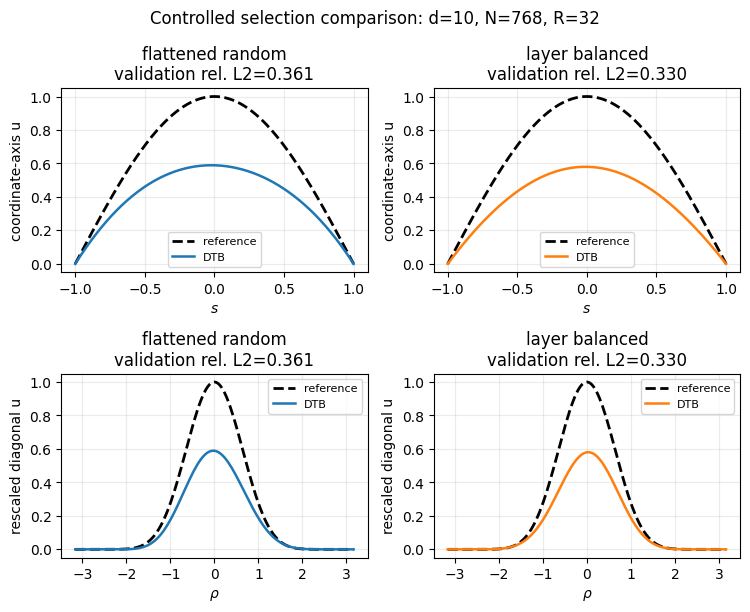

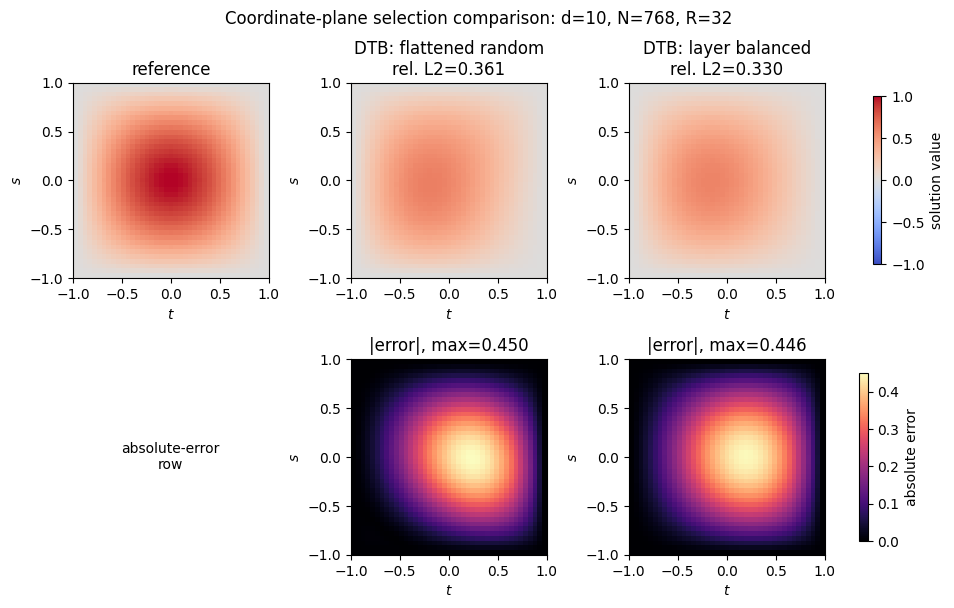

In [12]:
selection_visual_results = [
    next(
        result for result in r_results
        if result['config']['selection'] == strategy
        and result['config']['tangent_dimension'] == FIXED_R_FOR_N_SWEEP
    )
    for strategy in STRATEGIES
]
selection_labels = ['flattened random', 'layer balanced']
plot_line_comparison(
    selection_visual_results, selection_labels,
    f'Controlled selection comparison: d={D}, N={FIXED_N_FOR_R_SWEEP}, R={FIXED_R_FOR_N_SWEEP}',
)
plot_plane_comparison(
    selection_visual_results, selection_labels,
    f'Coordinate-plane selection comparison: d={D}, N={FIXED_N_FOR_R_SWEEP}, R={FIXED_R_FOR_N_SWEEP}',
)

### Controlled experiment B — increase tangent dimension at fixed sample count

**Purpose.** Visualize how the fitted solution changes when the tangent trial space grows but the quadrature information does not.

**Held fixed:** $d=10$, $N=768$, layer-balanced selection, initialization, Sobol points, ridge strength, and zero outer updates. **Changed:** $R\in\{16,32,64,128\}$. If $R$ becomes too large relative to $N$, unstable or weakly identified tangent directions may distort amplitude and shape even though the trial space is formally richer.

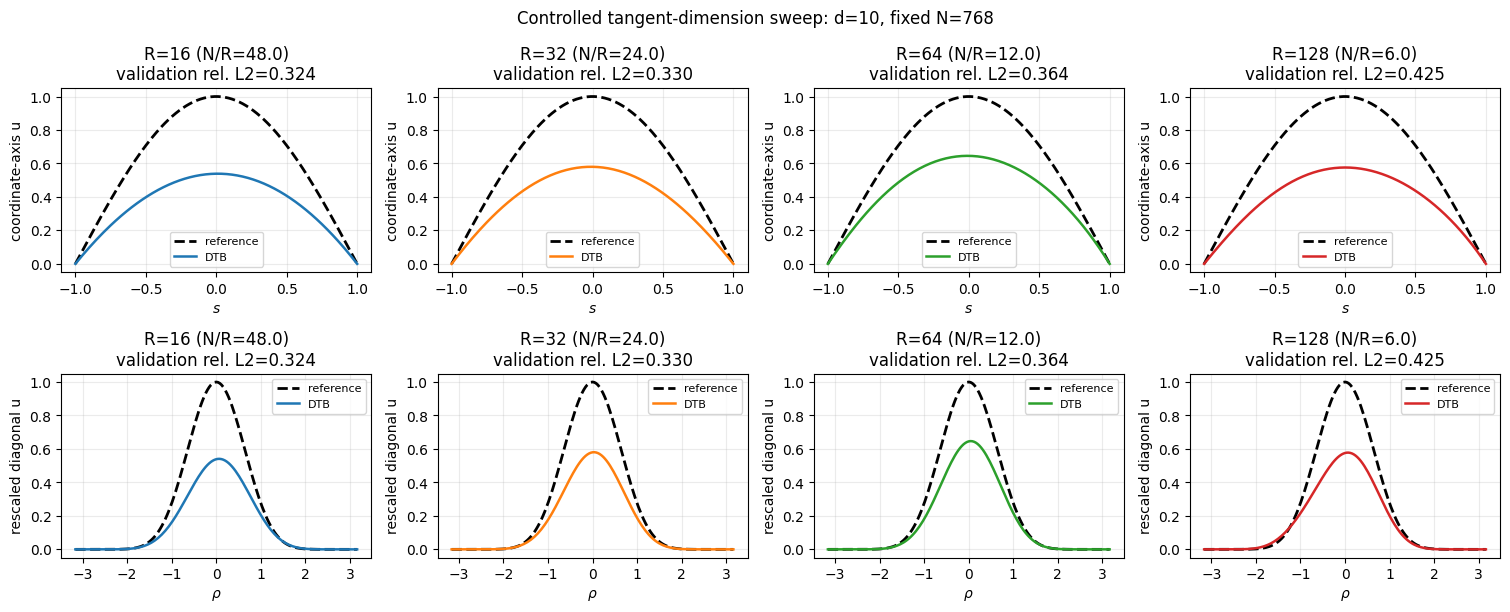

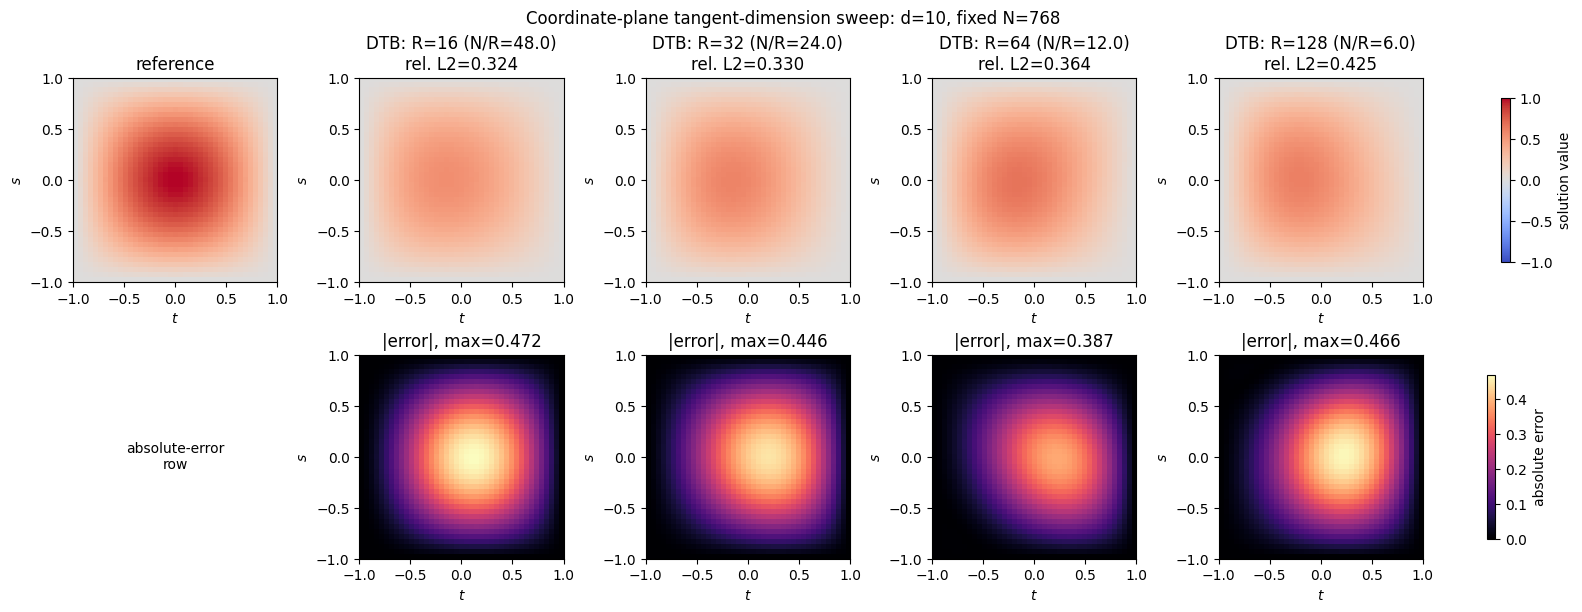

In [13]:
r_visual_results = [
    next(
        result for result in r_results
        if result['config']['selection'] == 'layer_balanced'
        and result['config']['tangent_dimension'] == R
    )
    for R in R_VALUES
]
r_labels = [f'R={R} (N/R={FIXED_N_FOR_R_SWEEP / R:.1f})' for R in R_VALUES]
plot_line_comparison(
    r_visual_results, r_labels,
    f'Controlled tangent-dimension sweep: d={D}, fixed N={FIXED_N_FOR_R_SWEEP}',
)
plot_plane_comparison(
    r_visual_results, r_labels,
    f'Coordinate-plane tangent-dimension sweep: d={D}, fixed N={FIXED_N_FOR_R_SWEEP}',
)

### Controlled experiment C — increase sample count at fixed tangent dimension

**Purpose.** Test whether spatial quadrature is the limiting factor by adding samples without enlarging the tangent space.

**Held fixed:** $d=10$, $R=32$, layer-balanced selected coordinates, initialization, ridge strength, and zero outer updates. **Changed:** $N\in\{768,2048,4096,16384\}$. The same Sobol seed is used, so each larger design extends the same deterministic low-discrepancy sequence. Improvement toward the reference as $N$ grows is evidence of quadrature/sample starvation at small $N$.

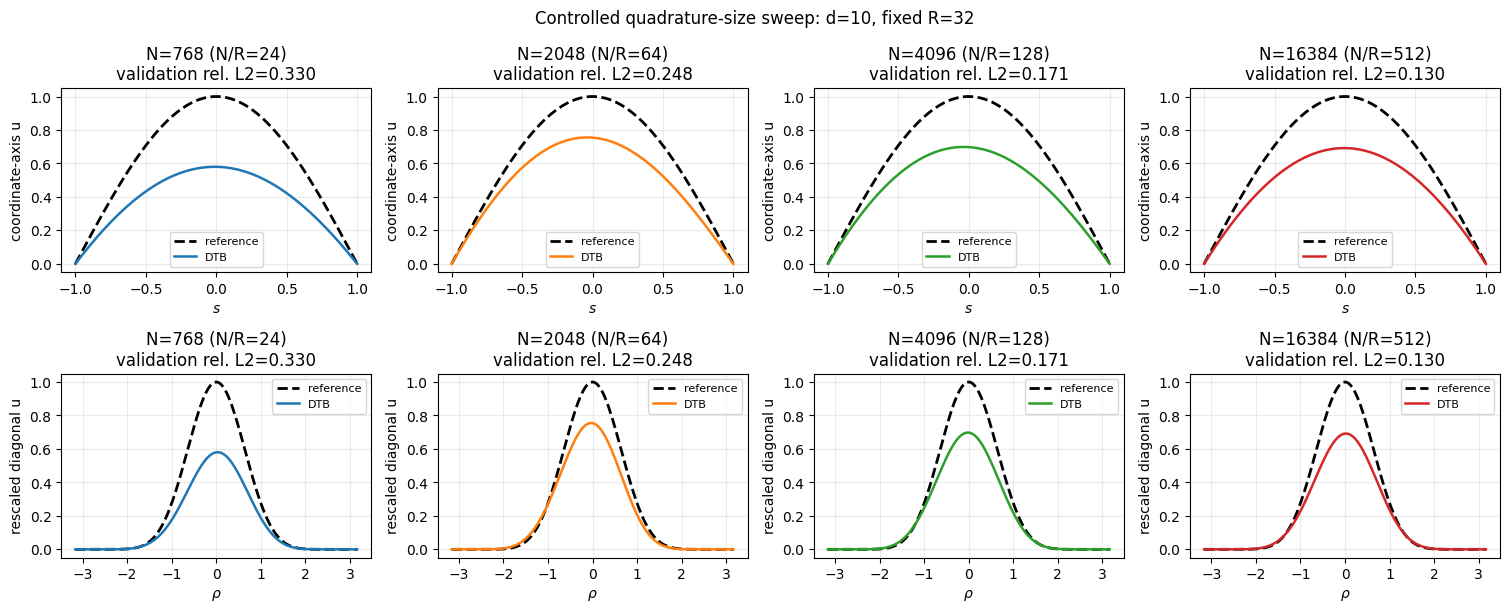

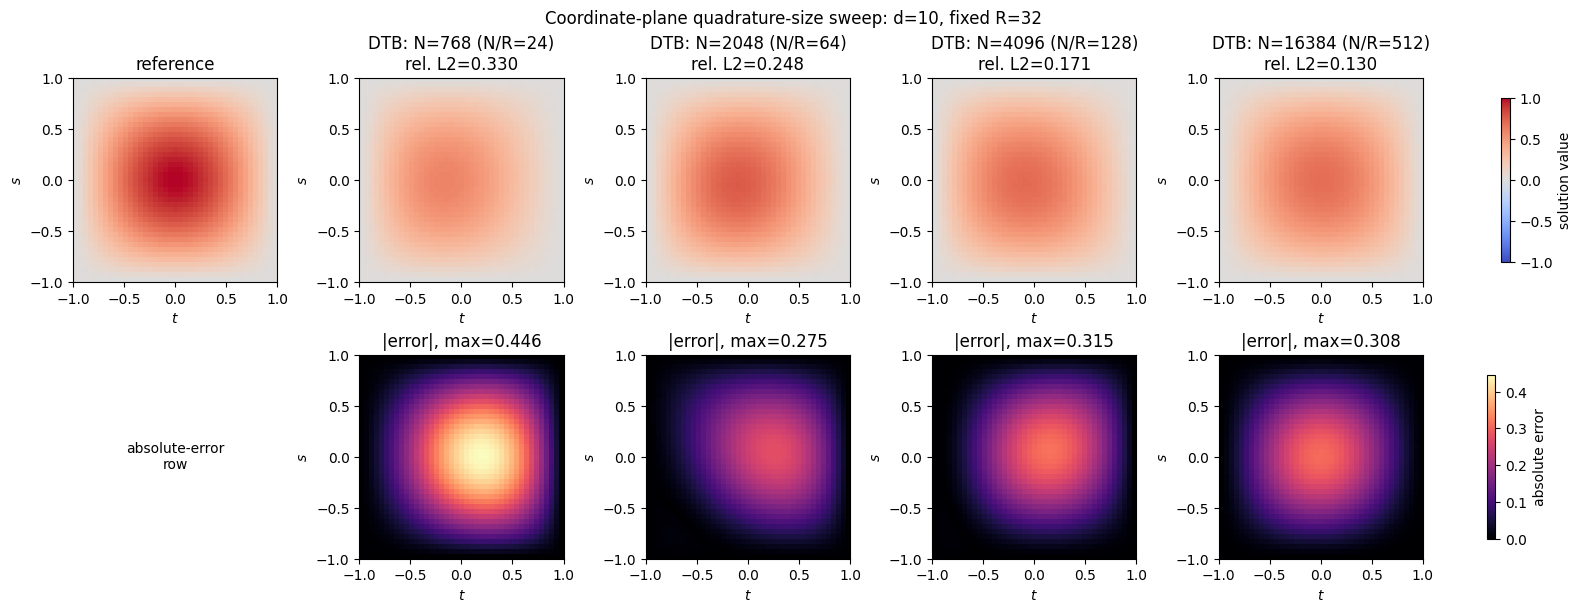

In [14]:
n_labels = [f'N={N} (N/R={N / FIXED_R_FOR_N_SWEEP:.0f})' for N in N_VALUES]
plot_line_comparison(
    n_results, n_labels,
    f'Controlled quadrature-size sweep: d={D}, fixed R={FIXED_R_FOR_N_SWEEP}',
)
plot_plane_comparison(
    n_results, n_labels,
    f'Coordinate-plane quadrature-size sweep: d={D}, fixed R={FIXED_R_FOR_N_SWEEP}',
)

### Controlled experiment D — outer-loop solution snapshots

**Purpose.** Check whether changes in the tangent basis alter the *actual approximating function*, and whether those changes move DTB toward the reference.

This is one continuous layer-balanced run with fixed $d=10$, $N=4096$, and $R=32$. The panels show outer iterations $k=0,4,8,12$; they are not independently restarted experiments. Compare visible prediction changes with the earlier tangent-feature and principal-angle diagnostics. Basis movement accompanied by growing solution error means the outer loop is active but optimizing an unhelpful empirical direction.

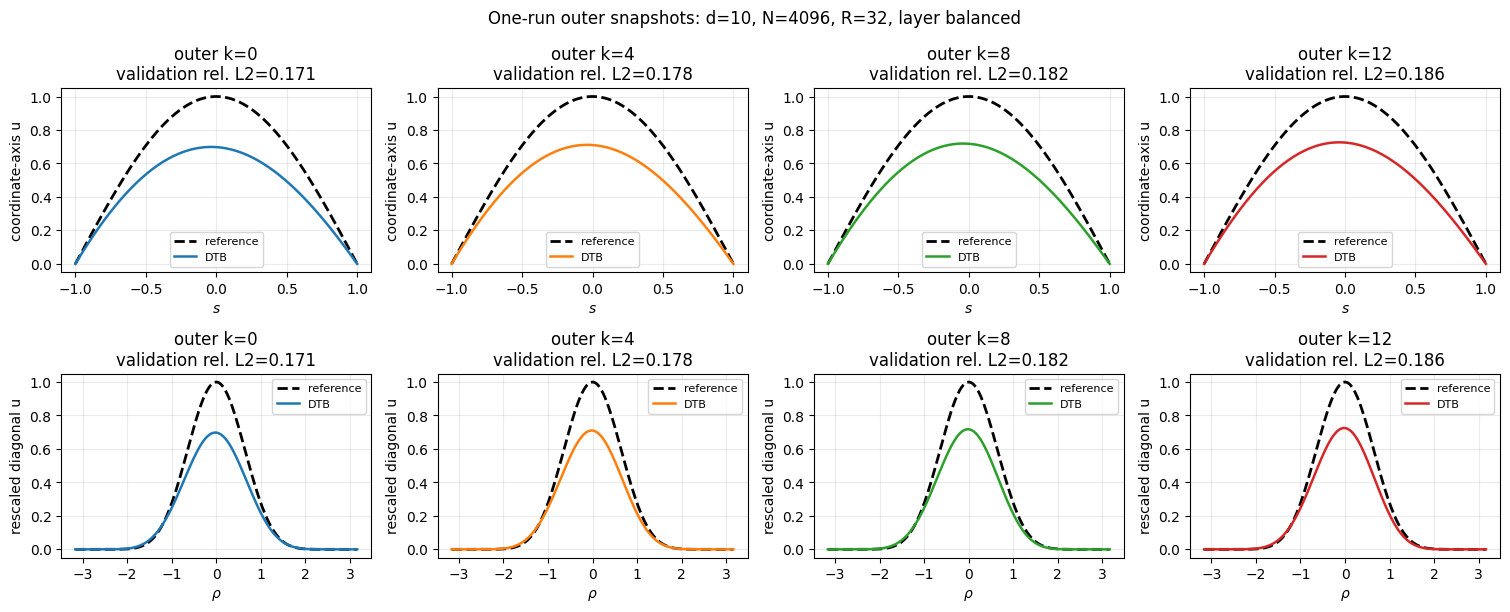

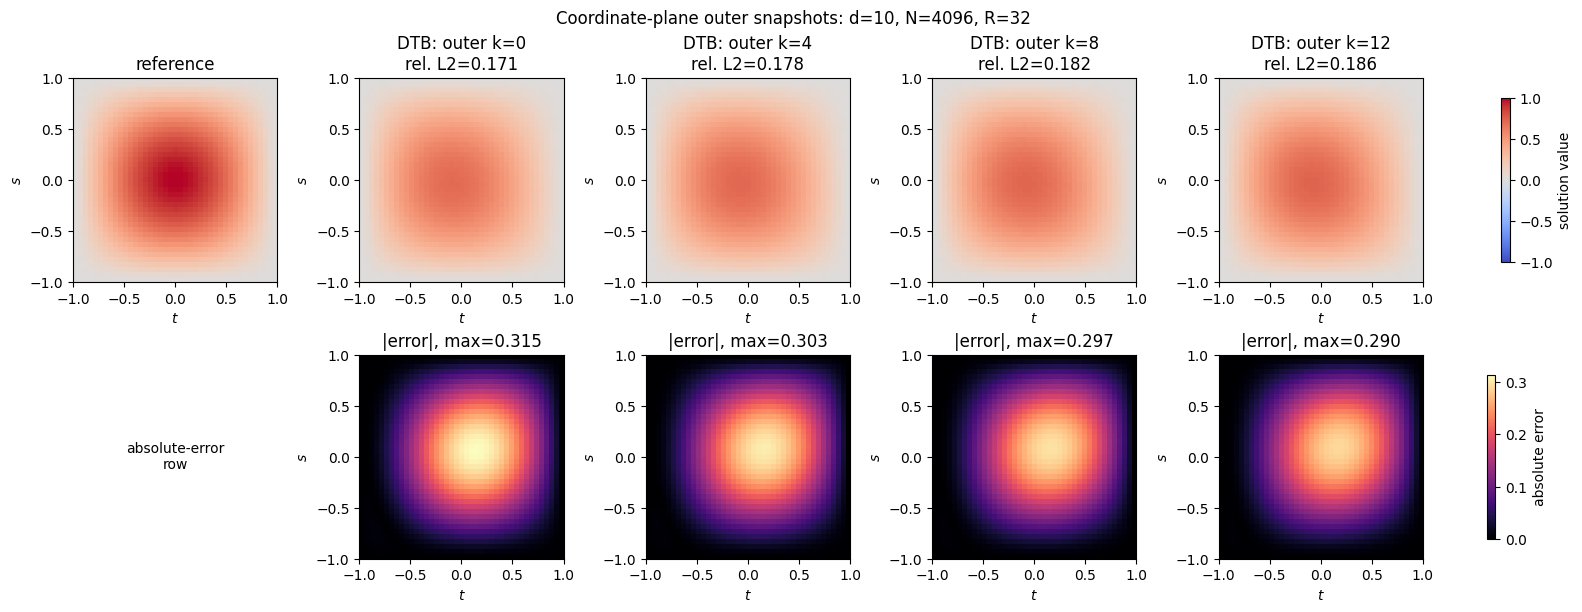

In [15]:
balanced_outer = next(
    result for result in outer_results
    if result['config']['selection'] == 'layer_balanced'
)
snapshot_steps = [0, 4, 8, 12]
snapshot_results = [balanced_outer] * len(snapshot_steps)
snapshot_labels = [f'outer k={step}' for step in snapshot_steps]
plot_line_comparison(
    snapshot_results, snapshot_labels,
    f'One-run outer snapshots: d={D}, N={OUTER_N}, R={OUTER_R}, layer balanced',
    steps=snapshot_steps,
)
plot_plane_comparison(
    snapshot_results, snapshot_labels,
    f'Coordinate-plane outer snapshots: d={D}, N={OUTER_N}, R={OUTER_R}',
    steps=snapshot_steps,
)

## Reading the diagnostics

Evidence of **quadrature limitation**: accuracy improves strongly with $N$, the exact-energy quadrature error falls, and useful-sample ESS remains much smaller than $N$.

Evidence of **tangent overfitting**: increasing $R$ lowers training $F$ while validation error, energy gap, or $\kappa(G)$ grows.

Evidence of **selection bias**: flattened-random allocation misses later layers and performs inconsistently relative to layer-balanced selection.

Evidence of an **ineffective outer loop**: tiny accepted steps, little subspace rotation, and decreasing training $F$ without lower validation error. Parameter movement alone is insufficient; the tangent span and prediction must change usefully.

### What the default controlled run shows

- Both selection rules strongly underestimate the central amplitude at $d=10$ and $N=768$; layer balancing improves validation relative $L^2$ only modestly ($0.361$ to $0.330$).
- At fixed $N=768$, enlarging $R$ does not systematically move the curves toward the reference. Validation relative $L^2$ worsens from about $0.324$ at $R=16$ to $0.425$ at $R=128$, consistent with the rapidly worsening stiffness conditioning.
- At fixed $R=32$, increasing $N$ gives the clearest improvement: validation relative $L^2$ falls from about $0.330$ to $0.130$. The solution still underestimates the peak, so quadrature starvation is important but is not the only limitation.
- During the layer-balanced outer run, tangent features and the solution visibly change, so the outer loop is active. Nevertheless validation relative $L^2$ rises from $0.171$ to $0.186$. The empirical outer objective is therefore not producing a useful global update in this configuration.

The coordinate plane is a measure-zero diagnostic subset of the full $d$-dimensional domain. Its maximum error can improve while independent full-dimensional $L^2$ error worsens, as happens in the outer snapshots. Use the slices to locate failure modes, but use the independent validation metrics to judge global performance.